# SF$_6$-like - calculate observational network global- annual-mean, latitudinal gradient and seasonality

Calculate global-mean, latitudinal gradient and seasonality
based on the observational network.
We also perform an EOF analysis for the latitudinal gradient.
We also perform an EOF analysis for the seasonality change.

## Imports

In [1]:
from pathlib import Path

import cf_xarray.units
import matplotlib.axes
import matplotlib.pyplot as plt
import pint_xarray
import xarray as xr
from pydoit_nb.config_handling import get_config_for_step_id

import local.binned_data_interpolation
import local.binning
import local.latitudinal_gradient
import local.mean_preserving_interpolation
import local.raw_data_processing
import local.seasonality
import local.xarray_space
import local.xarray_time
from local.config import load_config_from_file

In [2]:
cf_xarray.units.units.define("ppm = 1 / 1000000")
cf_xarray.units.units.define("ppb = ppm / 1000")
cf_xarray.units.units.define("ppt = ppb / 1000")

pint_xarray.accessors.default_registry = pint_xarray.setup_registry(cf_xarray.units.units)

## Define branch this notebook belongs to

In [3]:
step: str = "calculate_sf6_like_monthly_fifteen_degree_pieces"

## Parameters

In [4]:
config_file: str = "../../dev-config-absolute.yaml"  # config file
step_config_id: str = "ch2cl2"  # config ID to select for this branch

In [5]:
# Parameters
config_file = "/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/output-bundles/v1.0.0/v1.0.0-config.yaml"
step_config_id = "hfc4310mee"


## Load config

In [6]:
config = load_config_from_file(Path(config_file))
config_step = get_config_for_step_id(config=config, step=step, step_config_id=step_config_id)

## Action

### Load data

In [7]:
interpolated_spatial: xr.DataArray = xr.load_dataarray(  # type: ignore
    config_step.observational_network_interpolated_file
).pint.quantify()
interpolated_spatial

Magnitude,[[[0.182 0.182 0.182 ... 0.224 0.224 0.224] [0.182 0.182 0.182 ... 0.224 0.224 0.224] [0.182 0.182 0.182 ... 0.224 0.224 0.224] [0.182 0.182 0.182 ... 0.224 0.224 0.224] [0.182 0.182 0.182 ... 0.224 0.224 0.224] [0.182 0.182 0.182 ... 0.224 0.224 0.224]] [[0.182 0.182 0.182 ... 0.222 0.222 0.222] [0.182 0.182 0.182 ... 0.222 0.222 0.222] [0.182 0.182 0.182 ... 0.222 0.222 0.222] [0.182 0.182 0.182 ... 0.222 0.222 0.222] [0.182 0.182 0.182 ... 0.222 0.222 0.222] [0.182 0.182 0.182 ... 0.222 0.222 0.222]] [[0.186 0.186 0.186 ... 0.21066666666666667 0.21033333333333334 0.21] [0.186 0.186 0.186 ... 0.21066666666666667 0.21033333333333334 0.21] [0.186 0.186 0.186 ... 0.211 0.21033333333333332 0.21] [0.186 0.186 0.186 ... 0.223 0.2165 0.21] [0.186 0.186 0.186 ... 0.21683333333333335 0.21033333333333332 0.21] [0.186 0.186 0.186 ... 0.21066666666666664 0.21033333333333334 0.21]] ... [[0.303 0.303 0.303 ... 0.335 0.329 0.323] [0.303 0.303 0.303 ... 0.335 0.329 0.323] [0.303 0.303 0.303 ... 0.327 0.329 0.323] [0.303 0.303 0.303 ... 0.33 0.3265 0.323] [0.303 0.303 0.303 ... 0.3325 0.329 0.323] [0.303 0.303 0.303 ... 0.335 0.329 0.323]] [[0.304 0.304 0.304 ... 0.334 0.328 0.322] [0.304 0.304 0.304 ... 0.334 0.328 0.322] [0.304 0.304 0.304 ... 0.325 0.328 0.322] [0.304 0.304 0.304 ... 0.32 0.321 0.322] [0.304 0.304 0.304 ... 0.327 0.328 0.322] [0.304 0.304 0.304 ... 0.334 0.328 0.322]] [[0.304 0.304 0.304 ... 0.3333333333333333 0.32766666666666666 0.322] [0.304 0.304 0.304 ... 0.3333333333333333 0.3276666666666667 0.322] [0.304 0.304 0.304 ... 0.326 0.32766666666666666 0.322] [0.304 0.304 0.304 ... 0.327 0.3245 0.322] [0.304 0.304 0.304 ... 0.33016666666666666 0.32766666666666666 0.322] [0.304 0.304 0.304 ... 0.33333333333333337 0.32766666666666666 0.322]]]
Units,ppt


In [8]:
if config_step.year_drop_observational_data_before_and_including is not None:
    interpolated_spatial = interpolated_spatial.sel(
        time=interpolated_spatial["time"].dt.year
        > config_step.year_drop_observational_data_before_and_including
    )

if config_step.year_drop_observational_data_after_and_including is not None:
    interpolated_spatial = interpolated_spatial.sel(
        time=interpolated_spatial["time"].dt.year
        < config_step.year_drop_observational_data_after_and_including
    )

interpolated_spatial

Magnitude,[[[0.182 0.182 0.182 ... 0.224 0.224 0.224] [0.182 0.182 0.182 ... 0.224 0.224 0.224] [0.182 0.182 0.182 ... 0.224 0.224 0.224] [0.182 0.182 0.182 ... 0.224 0.224 0.224] [0.182 0.182 0.182 ... 0.224 0.224 0.224] [0.182 0.182 0.182 ... 0.224 0.224 0.224]] [[0.182 0.182 0.182 ... 0.222 0.222 0.222] [0.182 0.182 0.182 ... 0.222 0.222 0.222] [0.182 0.182 0.182 ... 0.222 0.222 0.222] [0.182 0.182 0.182 ... 0.222 0.222 0.222] [0.182 0.182 0.182 ... 0.222 0.222 0.222] [0.182 0.182 0.182 ... 0.222 0.222 0.222]] [[0.186 0.186 0.186 ... 0.21066666666666667 0.21033333333333334 0.21] [0.186 0.186 0.186 ... 0.21066666666666667 0.21033333333333334 0.21] [0.186 0.186 0.186 ... 0.211 0.21033333333333332 0.21] [0.186 0.186 0.186 ... 0.223 0.2165 0.21] [0.186 0.186 0.186 ... 0.21683333333333335 0.21033333333333332 0.21] [0.186 0.186 0.186 ... 0.21066666666666664 0.21033333333333334 0.21]] ... [[0.303 0.303 0.303 ... 0.335 0.329 0.323] [0.303 0.303 0.303 ... 0.335 0.329 0.323] [0.303 0.303 0.303 ... 0.327 0.329 0.323] [0.303 0.303 0.303 ... 0.33 0.3265 0.323] [0.303 0.303 0.303 ... 0.3325 0.329 0.323] [0.303 0.303 0.303 ... 0.335 0.329 0.323]] [[0.304 0.304 0.304 ... 0.334 0.328 0.322] [0.304 0.304 0.304 ... 0.334 0.328 0.322] [0.304 0.304 0.304 ... 0.325 0.328 0.322] [0.304 0.304 0.304 ... 0.32 0.321 0.322] [0.304 0.304 0.304 ... 0.327 0.328 0.322] [0.304 0.304 0.304 ... 0.334 0.328 0.322]] [[0.304 0.304 0.304 ... 0.3333333333333333 0.32766666666666666 0.322] [0.304 0.304 0.304 ... 0.3333333333333333 0.3276666666666667 0.322] [0.304 0.304 0.304 ... 0.326 0.32766666666666666 0.322] [0.304 0.304 0.304 ... 0.327 0.3245 0.322] [0.304 0.304 0.304 ... 0.33016666666666666 0.32766666666666666 0.322] [0.304 0.304 0.304 ... 0.33333333333333337 0.32766666666666666 0.322]]]
Units,ppt


### Drop out any years that have nan

These break everything later on

In [9]:
interpolated_spatial_no_year_with_nan = local.xarray_time.convert_time_to_year_month(
    interpolated_spatial
).dropna("year")
if interpolated_spatial_no_year_with_nan["year"].shape[0] != (
    interpolated_spatial_no_year_with_nan["year"].max()
    - interpolated_spatial_no_year_with_nan["year"].min()
    + 1
):
    msg = f"Missing years, this will not end well {interpolated_spatial_no_year_with_nan['year'].values=}"
    raise AssertionError(msg)

interpolated_spatial_no_year_with_nan

<xarray.DataArray 'hfc4310mee' (lon: 6, lat: 12, year: 12, month: 12)> Size: 83kB
<Quantity([[[[0.194      0.19       0.191      ... 0.211      0.209
    0.212     ]
   [0.207      0.209      0.21       ... 0.23       0.229
    0.227     ]
   [0.227      0.229      0.23       ... 0.233      0.234
    0.233     ]
   ...
   [0.28       0.283      0.283      ... 0.293      0.292
    0.29      ]
   [0.29       0.291      0.292      ... 0.298      0.298
    0.296     ]
   [0.296      0.295      0.295      ... 0.303      0.304
    0.304     ]]

  [[0.194      0.19       0.191      ... 0.211      0.209
    0.212     ]
   [0.207      0.209      0.21       ... 0.23       0.229
    0.227     ]
   [0.227      0.229      0.23       ... 0.233      0.234
    0.233     ]
...
   [0.30466667 0.30833333 0.312      ... 0.31366667 0.315
    0.31633333]
   [0.31666667 0.316      0.31966667 ... 0.322      0.321
    0.32433333]
   [0.323      0.321      0.328      ... 0.329      0.328
    0.32766667]]

  [[0.215      0.22       0.22       ... 0.231      0.233
    0.237     ]
   [0.235      0.235      0.237      ... 0.242      0.242
    0.246     ]
   [0.245      0.245      0.245      ... 0.251      0.251
    0.253     ]
   ...
   [0.299      0.304      0.312      ... 0.31       0.314
    0.316     ]
   [0.316      0.313      0.318      ... 0.321      0.32
    0.322     ]
   [0.32       0.317      0.327      ... 0.323      0.322
    0.322     ]]]], 'ppt')>
Coordinates:
  * year     (year) int64 96B 2011 2012 2013 2014 2015 ... 2019 2020 2021 2022
  * month    (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
  * lat      (lat) float64 96B -82.5 -67.5 -52.5 -37.5 ... 37.5 52.5 67.5 82.5
  * lon      (lon) float64 48B -150.0 -90.0 -30.0 30.0 90.0 150.0
Attributes:
    description:  Interpolated spatial data

In [10]:
interpolated_spatial_nan_free = local.xarray_time.convert_year_month_to_time(
    interpolated_spatial_no_year_with_nan
)
interpolated_spatial_nan_free

Magnitude,[[[0.194 0.19 0.191 ... 0.303 0.304 0.304] [0.194 0.19 0.191 ... 0.303 0.304 0.304] [0.194 0.19 0.191 ... 0.303 0.304 0.304] ... [0.22166666666666668 0.22733333333333333 0.22533333333333333 ... 0.335 0.334 0.3333333333333333] [0.21833333333333332 0.22366666666666668 0.22266666666666668 ... 0.329 0.328 0.32766666666666666] [0.215 0.22 0.22 ... 0.323 0.322 0.322]] [[0.194 0.19 0.191 ... 0.303 0.304 0.304] [0.194 0.19 0.191 ... 0.303 0.304 0.304] [0.194 0.19 0.191 ... 0.303 0.304 0.304] ... [0.22166666666666668 0.22733333333333333 0.22533333333333333 ... 0.335 0.334 0.3333333333333333] [0.21833333333333332 0.22366666666666665 0.22266666666666665 ... 0.329 0.328 0.3276666666666667] [0.215 0.22 0.22 ... 0.323 0.322 0.322]] [[0.194 0.19 0.191 ... 0.303 0.304 0.304] [0.194 0.19 0.191 ... 0.303 0.304 0.304] [0.194 0.19 0.191 ... 0.303 0.304 0.304] ... [0.21575 0.227 0.23600000000000002 ... 0.327 0.325 0.326] [0.21833333333333332 0.22366666666666668 0.22266666666666668 ... 0.329 0.328 0.32766666666666666] [0.215 0.22 0.22 ... 0.323 0.322 0.322]] [[0.194 0.19 0.191 ... 0.303 0.304 0.304] [0.194 0.19 0.191 ... 0.303 0.304 0.304] [0.194 0.19 0.191 ... 0.303 0.304 0.304] ... [0.23 0.233 0.236 ... 0.33 0.32 0.327] [0.2225 0.2265 0.22799999999999998 ... 0.3265 0.321 0.3245] [0.215 0.22 0.22 ... 0.323 0.322 0.322]] [[0.194 0.19 0.191 ... 0.303 0.304 0.304] [0.194 0.19 0.191 ... 0.303 0.304 0.304] [0.194 0.19 0.191 ... 0.303 0.304 0.304] ... [0.22583333333333333 0.23016666666666666 0.23066666666666666 ... 0.3325 0.327 0.33016666666666666] [0.21833333333333332 0.22366666666666668 0.22266666666666668 ... 0.329 0.328 0.32766666666666666] [0.215 0.22 0.22 ... 0.323 0.322 0.322]] [[0.194 0.19 0.191 ... 0.303 0.304 0.304] [0.194 0.19 0.191 ... 0.303 0.304 0.304] [0.194 0.19 0.191 ... 0.303 0.304 0.304] ... [0.22166666666666668 0.22733333333333333 0.22533333333333333 ... 0.335 0.334 0.33333333333333337] [0.21833333333333335 0.22366666666666668 0.22266666666666668 ... 0.329 0.328 0.32766666666666666] [0.215 0.22 0.22 ... 0.323 0.322 0.322]]]
Units,ppt


### Longitudinal-mean

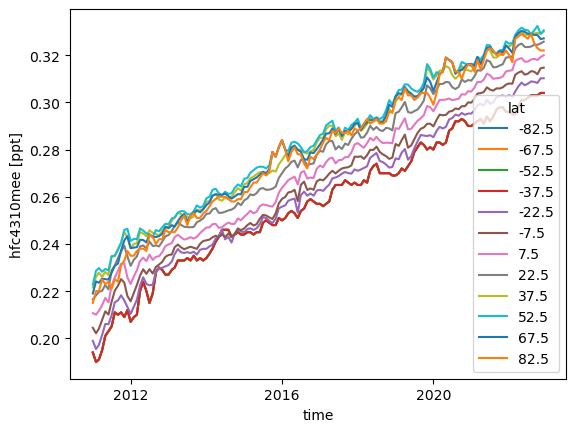

In [11]:
lon_mean = interpolated_spatial_nan_free.mean(dim="lon")
lon_mean.plot(hue="lat")  # type: ignore

### Global-, annual-mean

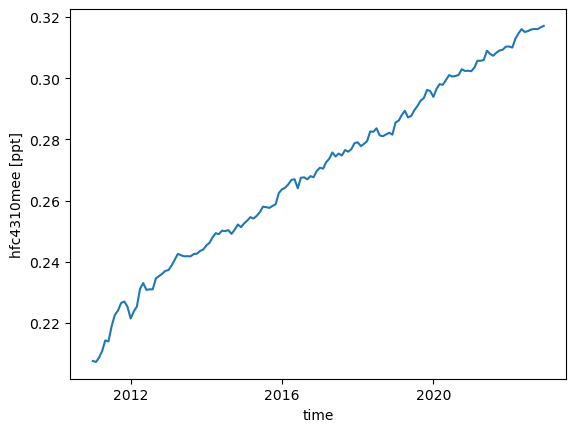

In [12]:
global_mean = local.xarray_space.calculate_global_mean_from_lon_mean(lon_mean)
global_mean.plot()  # type: ignore

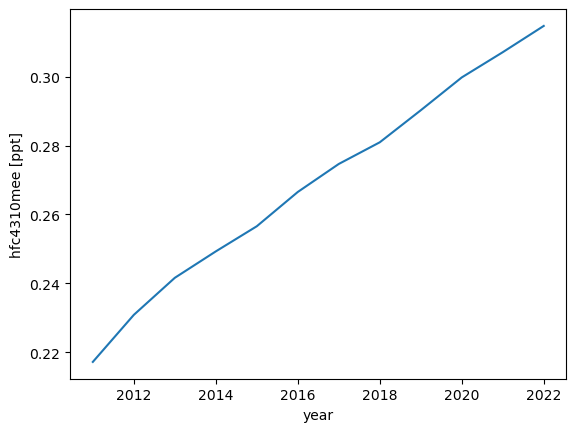

In [13]:
global_annual_mean = global_mean.groupby("time.year").mean()
global_annual_mean.plot()  # type: ignore

### Latitudinal gradient

In [14]:
(
    lat_residuals_annual_mean,
    lat_gradient_full_eofs_pcs,
) = local.latitudinal_gradient.calculate_eofs_pcs(lon_mean, global_mean)
lat_gradient_full_eofs_pcs

Magnitude,[[0.32568006589935594 -0.2896522439689965 0.08133940616711911 0.11176481552228823 -0.014698096696338423 0.013351180933956508 -0.004331912733187673 -0.025769707651013215 0.22096888768351347 0.8585099020463958 -0.062227495988679285 0.01052166256680516] [0.32568006589935583 -0.2896522439689966 0.0813394061671177 0.11176481552228923 -0.014698096696334378 0.013351180933957063 -0.004331912733190499 -0.025769707650997675 0.16506147881317088 -0.30784273391408173 -0.40394698061655926 -0.7103969764259076] [0.32568006589935605 -0.28965224396899675 0.08133940616711773 0.1117648155222892 -0.014698096696334366 0.013351180933957615 -0.004331912733189554 -0.025769707650997727 0.17122884221524964 -0.32637087437895096 -0.39857065721837304 0.7036715391652921] [0.32568006589935605 -0.2896522439689967 0.0813394061671174 0.11176481552228873 -0.014698096696336873 0.013351180933958907 -0.004331912733184047 -0.025769707651003452 0.23961347882154657 -0.24697665306044758 0.819379444700147 -0.007396424066154539] [0.20700826596328345 0.0903600887877187 -0.3121968199653701 -0.7409790179262151 0.2580954061057857 0.019905375651034982 0.20321339410222522 0.21403363078770796 0.3843810314221447 -0.010940141430199073 -0.021882680444761285 -0.0017365987494983384] [0.10300718866053558 0.3811692515931178 -0.26403380663855675 0.035081907493826135 -0.4346315038218226 -0.07203964618668646 -0.6218167815213704 -0.14684155115358033 0.4124916561112914 -0.011740217876882307 -0.02348300867869806 -0.0018636000104658868] [-0.04276740213827154 0.365170345605372 -0.06443814207827042 0.48362039657542505 -0.10060426807805642 -0.161100359998949 0.5569242052538808 0.3312089475581201 0.41249165611147764 -0.011740217876881795 -0.02348300867871176 -0.0018636000104672423] [-0.20362817316247017 0.16023624011551893 0.14078303432653042 0.0801415769546817 0.4086241384850423 0.27546414953372056 0.11507264437111724 -0.7086403531646835 0.3843810314220815 -0.010940141430207521 -0.021882680444760806 -0.001736598749498309] [-0.34815364477393196 -0.09292375914302571 0.3840317553652305 0.059570941083687795 0.4141311137877711 -0.06840929854281182 -0.4496224506285069 0.4810269891912041 0.33007547466107373 -0.009394512424482313 -0.018791083701335757 -0.001491251153615607] [-0.3982562633793846 -0.2913349438995016 0.3160929907887142 -0.32689901763991946 -0.47600691368337783 -0.42530034623645013 0.19953071318930268 -0.1950714248104856 0.2532758197773732 -0.007208662922218024 -0.014418905657410655 -0.0011442772560243122] [-0.3405955095118751 -0.29050769444286023 -0.20142741499724687 0.01331729423600931 -0.33267372499298686 0.7628016635760074 0.05612743414032698 0.1941861413559997 0.1592158363340242 -0.004531554954667436 -0.009064103021298571 -0.0007193227544425641] [-0.28835616731606994 -0.41715792838265536 -0.7031462082648058 0.22102824114331987 0.24034185477428413 -0.35276143639540464 -0.05868320411944943 -0.1046530111289843 0.054305556761017865 -0.001545629005711394 -0.0030915967434166918 -0.00024534759588160044]]
Units,ppt
Magnitude,[[-0.04181753084820922 0.004322919472107218 0.003698612667928791 -8.150991708518592e-05 -0.0002749291635687653 -5.688555477149878e-05 1.7468282607345053e-05 -1.317968680539751e-05 1.0593647947297671e-17 1.0513789039058623e-18 2.3919575779877834e-19 -3.3485519071059773e-21] [-0.0342165008665234 0.00034554025378137344 0.0015118660465659804 0.0006176313330940555 8.706193687265614e-05 -0.0001110143838133769 -0.00012569809879139918 7.270691812320928e-06 -1.095461290334304e-17 -8.002397384258416e-19 -7.004865986676798e-19 2.29824399392024e-20] [-0.02869071123491853 0.00017877823087783667 0.0007220954313481643 -0.00035107853315707285 0.00037211463966817313 -3.0075227859225163e-06 4.499342483365291e-05 -3.3733305242068282e-06 -3.2474377745794465e-17 1.0657544268262487e-18 -3.333509121711904e-19 -2.4532336795748097e-20] [-0.027481432461937235 -0.0057025112526552625 0.0018385853330165093 0.0002007528359217478 0.0003082968726889401 0.00024915527060301844 5.720444802393794e

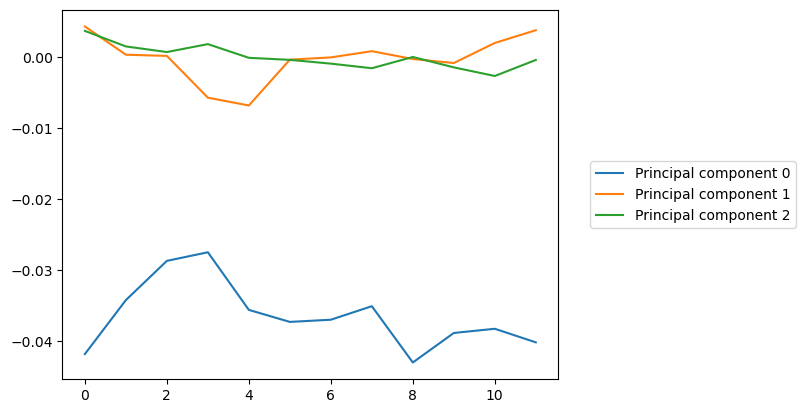

In [15]:
fig, ax = plt.subplots()
n_eofs_to_show = 3

for i in range(n_eofs_to_show):
    ax.plot(
        lat_gradient_full_eofs_pcs["principal-components"].sel(eof=i).data.m,
        label=f"Principal component {i}",
    )

ax.legend(loc="center left", bbox_to_anchor=(1.05, 0.5))

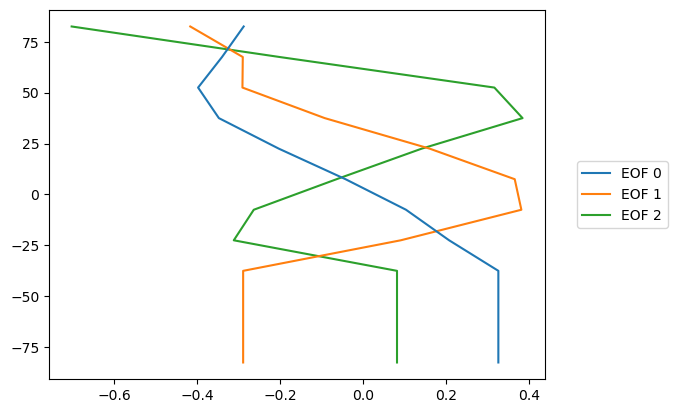

In [16]:
fig, ax = plt.subplots()

for i in range(3):
    ax.plot(
        lat_gradient_full_eofs_pcs["eofs"].sel(eof=i).data.m,
        lat_gradient_full_eofs_pcs["lat"].data,
        label=f"EOF {i}",
        zorder=2 - i / 10,
    )

ax.legend(loc="center left", bbox_to_anchor=(1.05, 0.5))

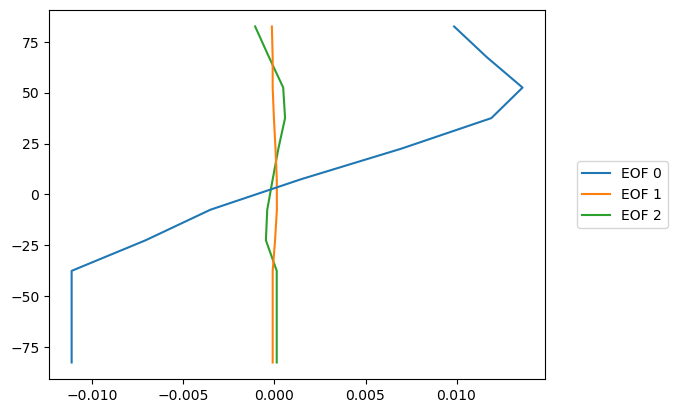

In [17]:
fig, ax = plt.subplots()

for i in range(3):
    ax.plot(
        lat_gradient_full_eofs_pcs["principal-components"].sel(eof=i).isel(year=1)
        @ lat_gradient_full_eofs_pcs["eofs"].sel(eof=i),
        lat_gradient_full_eofs_pcs["lat"],
        label=f"EOF {i}",
        zorder=2 - i / 10,
    )

ax.legend(loc="center left", bbox_to_anchor=(1.05, 0.5))

In [18]:
lat_gradient_eofs_pcs = lat_gradient_full_eofs_pcs.sel(eof=range(config_step.lat_gradient_n_eofs_to_use))
lat_gradient_eofs_pcs

Magnitude,[[0.32568006589935594] [0.32568006589935583] [0.32568006589935605] [0.32568006589935605] [0.20700826596328345] [0.10300718866053558] [-0.04276740213827154] [-0.20362817316247017] [-0.34815364477393196] [-0.3982562633793846] [-0.3405955095118751] [-0.28835616731606994]]
Units,ppt
Magnitude,[[-0.04181753084820922] [-0.0342165008665234] [-0.02869071123491853] [-0.027481432461937235] [-0.035597250030344293] [-0.03728931022285137] [-0.03698185287412697] [-0.035077340341061206] [-0.0430039534169006] [-0.03884642708866772] [-0.038257227344792116] [-0.0401690432018258]]
Units,dimensionless


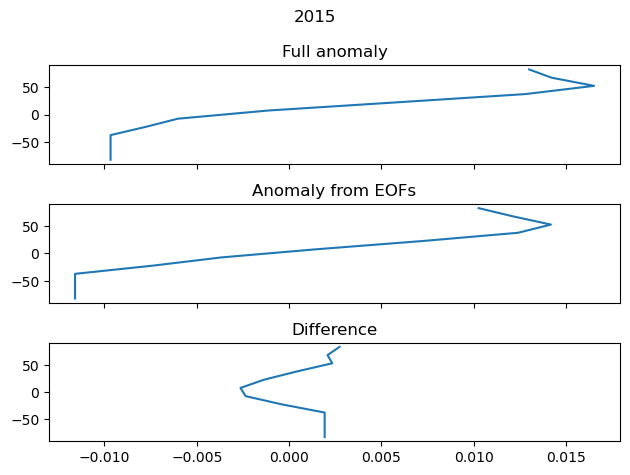

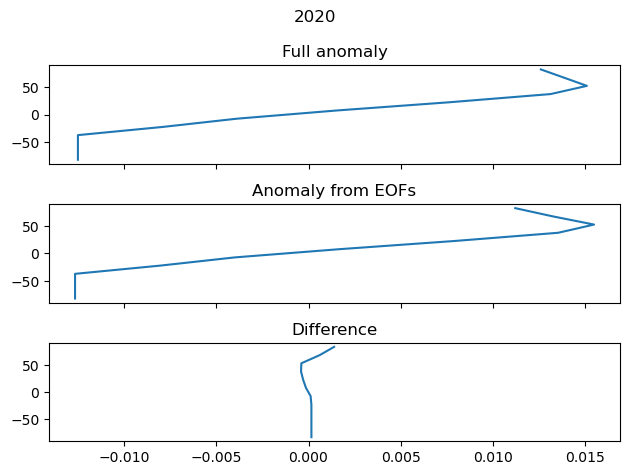

In [19]:
latitudinal_anomaly_from_eofs = lat_gradient_eofs_pcs["principal-components"] @ lat_gradient_eofs_pcs["eofs"]

for year in latitudinal_anomaly_from_eofs["year"]:
    if year % 5:
        continue

    fig, axes = plt.subplots(nrows=3, sharex=True, sharey=True)
    if isinstance(axes, matplotlib.axes.Axes):
        raise TypeError(type(axes))

    selected = lat_residuals_annual_mean.sel(year=year)
    axes[0].plot(selected.data.m, lat_residuals_annual_mean.lat)
    axes[0].set_title("Full anomaly")

    selected_eofs = latitudinal_anomaly_from_eofs.sel(year=year)
    axes[1].plot(selected_eofs.data.m, latitudinal_anomaly_from_eofs.lat)
    axes[1].set_title("Anomaly from EOFs")

    axes[2].plot(selected.data.m - selected_eofs.data.m, lat_residuals_annual_mean.lat)
    axes[2].set_title("Difference")

    axes[0].set_ylim([-90, 90])

    plt.suptitle(str(int(year)))
    plt.tight_layout()
    plt.show()

### Seasonality

In [20]:
(
    seasonality,
    relative_seasonality,
    lon_mean_ym_monthly_anomalies,
) = local.seasonality.calculate_seasonality(
    lon_mean=lon_mean,
    global_mean=global_mean,
)

/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/src/local/seasonality.py:29: UserWarning: The `squeeze` kwarg to GroupBy is being removed.Pass .groupby(..., squeeze=False) to disable squeezing, which is the new default, and to silence this warning.
  lon_mean_ym_annual_mean_monthly = lon_mean_ym_annual_mean.groupby("lat", squeeze=True).apply(  # type: ignore
/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/.pixi/envs/all-dev/lib/python3.11/importlib/__init__.py:126: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  return _bootstrap._gcd_import(name[level:], package, level)


Calculating output values:   0%|                                                                                                                                                                                      | 0/144 [00:00<?, ?it/s]

Calculating output values: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 144/144 [00:00<00:00, 13267.87it/s]


/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/src/local/seasonality.py:29: UserWarning: The `squeeze` kwarg to GroupBy is being removed.Pass .groupby(..., squeeze=False) to disable squeezing, which is the new default, and to silence this warning.
  lon_mean_ym_annual_mean_monthly = lon_mean_ym_annual_mean.groupby("lat", squeeze=True).apply(  # type: ignore


Calculating output values:   0%|                                                                                                                                                                                      | 0/144 [00:00<?, ?it/s]

...

Calculating output values:   0%|                                                                                                                                                                                      | 0/144 [00:00<?, ?it/s]

Calculating output values: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 144/144 [00:00<00:00, 19443.70it/s]


/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/src/local/seasonality.py:29: UserWarning: The `squeeze` kwarg to GroupBy is being removed.Pass .groupby(..., squeeze=False) to disable squeezing, which is the new default, and to silence this warning.
  lon_mean_ym_annual_mean_monthly = lon_mean_ym_annual_mean.groupby("lat", squeeze=True).apply(  # type: ignore


Calculating output values:   0%|                                                                                                                                                                                      | 0/144 [00:00<?, ?it/s]

Calculating output values: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 144/144 [00:00<00:00, 18992.48it/s]

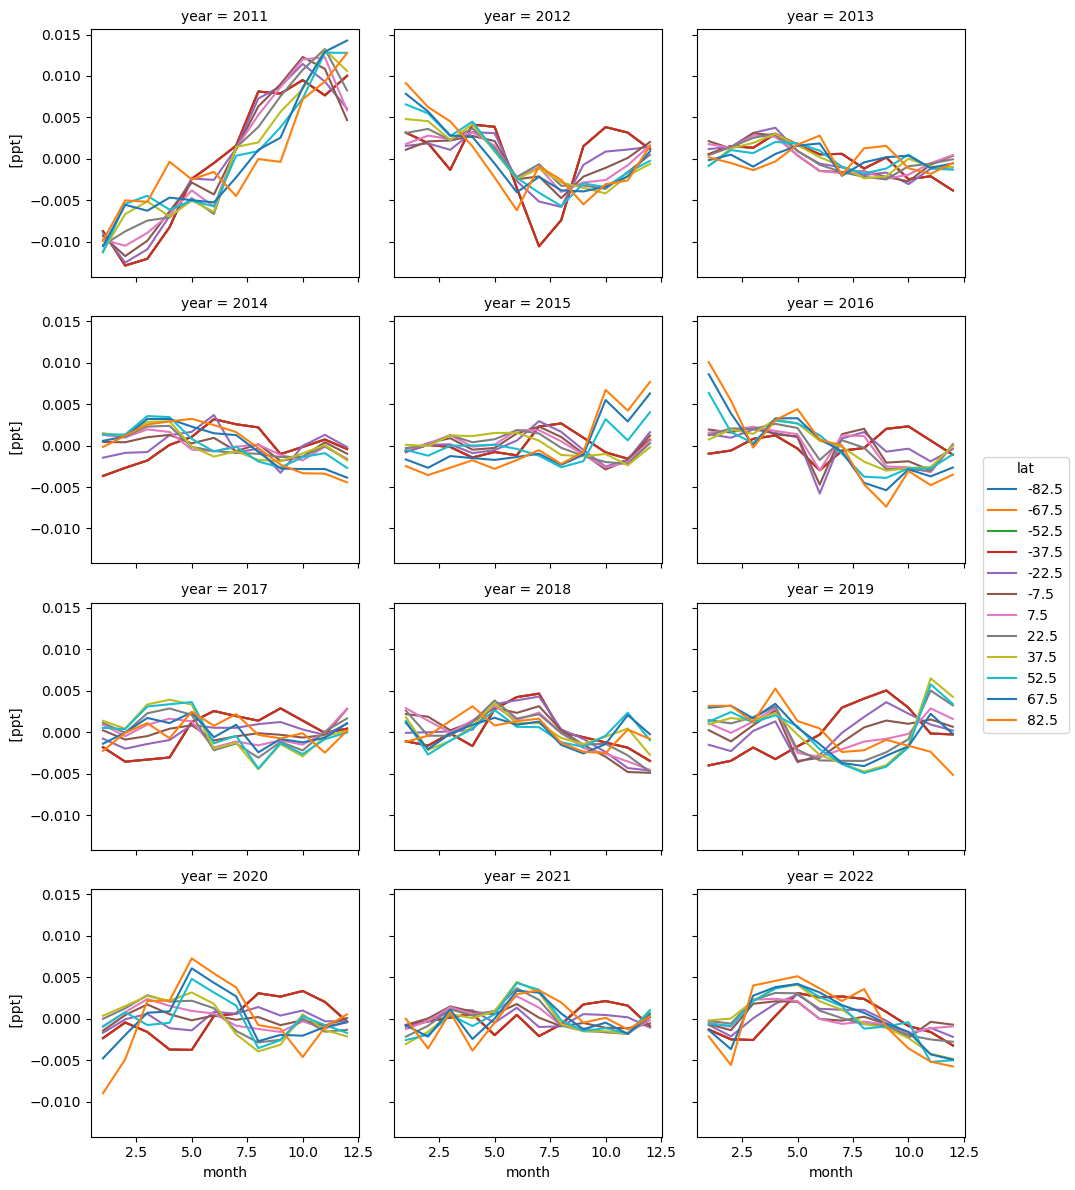

In [21]:
lon_mean_ym_monthly_anomalies.plot.line(hue="lat", col="year", col_wrap=3)

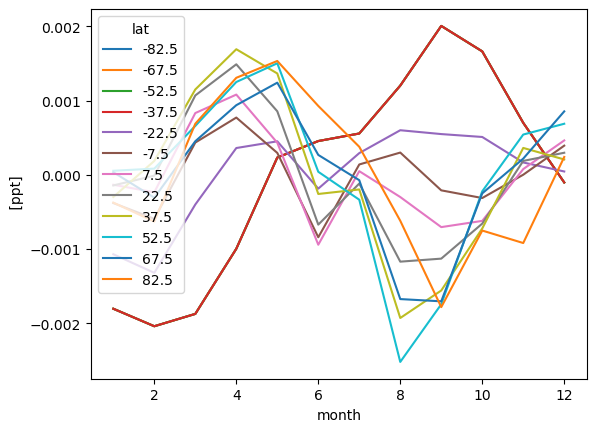

In [22]:
seasonality.plot.line(hue="lat")

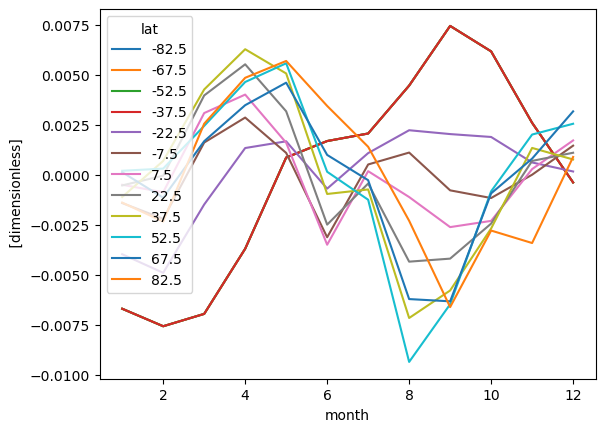

In [23]:
relative_seasonality.plot.line(hue="lat")

### Save

In [24]:
config_step.observational_network_global_annual_mean_file.parent.mkdir(exist_ok=True, parents=True)
global_annual_mean.pint.dequantify().to_netcdf(config_step.observational_network_global_annual_mean_file)
global_annual_mean

Magnitude,[0.21724266776575107 0.23088745303014055 0.24163189716412992 0.24929419031115074 0.2565864327187329 0.26652791729774455 0.27465153701660866 0.2809343119571032 0.29021916773807654 0.29974594454523806 0.3070601229109557 0.31468334600267117]
Units,ppt


In [25]:
config_step.observational_network_latitudinal_gradient_eofs_file.parent.mkdir(exist_ok=True, parents=True)
lat_gradient_eofs_pcs.pint.dequantify().to_netcdf(
    config_step.observational_network_latitudinal_gradient_eofs_file
)
lat_gradient_eofs_pcs

Magnitude,[[0.32568006589935594] [0.32568006589935583] [0.32568006589935605] [0.32568006589935605] [0.20700826596328345] [0.10300718866053558] [-0.04276740213827154] [-0.20362817316247017] [-0.34815364477393196] [-0.3982562633793846] [-0.3405955095118751] [-0.28835616731606994]]
Units,ppt
Magnitude,[[-0.04181753084820922] [-0.0342165008665234] [-0.02869071123491853] [-0.027481432461937235] [-0.035597250030344293] [-0.03728931022285137] [-0.03698185287412697] [-0.035077340341061206] [-0.0430039534169006] [-0.03884642708866772] [-0.038257227344792116] [-0.0401690432018258]]
Units,dimensionless


In [26]:
# Use relative seasonality
config_step.observational_network_seasonality_file.parent.mkdir(exist_ok=True, parents=True)
relative_seasonality.pint.dequantify().to_netcdf(config_step.observational_network_seasonality_file)
relative_seasonality

Magnitude,[[-0.006699670030963145 -0.007575558461895885 -0.006957790828229115 -0.0036987727888531797 0.0008655660352249728 0.001689843726980593 0.0020675510561505503 0.0044637124798717065 0.007449555897842552 0.006175649837657046 0.002601365823696529 -0.00038150729377642143] [-0.006699670030963145 -0.007575558461895885 -0.006957790828229115 -0.0036987727888531797 0.0008655660352249728 0.001689843726980593 0.0020675510561505503 0.0044637124798717065 0.007449555897842552 0.006175649837657046 0.002601365823696529 -0.00038150729377642143] [-0.006699670030963145 -0.007575558461895885 -0.006957790828229115 -0.0036987727888531797 0.0008655660352249728 0.001689843726980593 0.0020675510561505503 0.0044637124798717065 0.007449555897842552 0.006175649837657046 0.002601365823696529 -0.00038150729377642143] [-0.006699670030963145 -0.007575558461895885 -0.0069577908282291235 -0.0036987727888531797 0.0008655660352249641 0.001689843726980696 0.0020675510561505594 0.004463712479871741 0.007449555897842526 0.006175649837657012 0.002601365823696632 -0.00038150729377652454] [-0.003973001935407287 -0.004902627597765212 -0.001484278622099092 0.0013405660800355473 0.0016760551049518633 -0.0006912326298861917 0.001086441165114923 0.002230858696791607 0.0020384236623871236 0.0018936090576146354 0.0006179063074590621 0.00016724099117596192] [-0.0014120593619832758 -0.0021991222390799242 0.00161468089503048 0.002864801105189145 0.0010971764472846386 -0.0031233485555544485 0.0005179354231421312 0.0011133764663213452 -0.0007766264194593339 -0.0011609119899969084 4.9310571560474975e-06 0.0014591442315113926] [-0.0004975225611160137 -0.0008725947383979481 0.003090115821245563 0.004013908094283806 0.00160533052897371 -0.0034974669405305925 0.00018251053922757493 -0.001111095162813945 -0.002615831690393687 -0.002304575446900593 0.00028713028023458225 0.0017200682093132646] [-0.000531174306793189 -4.2110998479957984e-05 0.003971383668934493 0.005528887590720805 0.0031778116903310636 -0.002491367803353595 -0.000436218939124863 -0.004344116512729775 -0.004192943434556741 -0.0024406017425328184 0.000696258663272241 0.0011041539263881228] [-0.0011095991239342 0.0006956597507874079 0.004271039850251584 0.006283320999340945 0.005070618884242147 -0.0009579745128162245 -0.0007314684546770284 -0.007163177822590383 -0.005787015380724887 -0.0026849136213579587 0.0013452349219693555 0.0007682214422678186] [0.0002023787757594519 0.0003111714848730703 0.002447810119736441 0.004644090487171702 0.00558009043873888 0.00015241155057942163 -0.0012454345657688687 -0.009360589655965602 -0.006476395708204136 -0.00082507108986261 0.002014903362514531 0.0025545875682086044] [0.0001314762375257817 -0.0011447639171914994 0.0016804310897675682 0.0034836914341958756 0.00461052854262999 0.0009955393682940289 -0.0002686360637198761 -0.0062164903359036095 -0.006328899283566982 -0.0009277680904950849 0.0008105076900510847 0.0031743496442317] [-0.0013894049407994682 -0.002341268370697077 0.0025560496563541723 0.0048538385893700875 0.005696110323319539 0.00344642819116823 0.0014027789966666157 -0.002299189336828204 -0.006617878072340105 -0.0027878153868637597 -0.003412501936134009 0.0008928317286683903]]
Units,dimensionless
